In [1]:
import os
import sys
import shutil

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import yaml
from chroma import structure, plotting
from OpenMiChroM.CndbTools import cndbTools
import seaborn as sns

from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

# tex_path = "/opt/apps/software/texlive/20230313-GCC-13.2.0/bin/x86_64-linux"
# if tex_path not in os.environ["PATH"]:
#     os.environ["PATH"] = tex_path + os.pathsep + os.environ["PATH"]

plt.style.use("chroma.tex")

# nuclear bodies as fields

## chr1


In [2]:
conditions = ["complete", "nucleolus", "lamina", "control"]

NUM_REPLICAS = 32
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

chromosome = 1

folder_num = 4 if chromosome == 1 else 5

OUTPUT_FOLDER = f"/scratch/mm146/Polarization/{folder_num}_IMR-90_hg38_chr{chromosome}/4_analysis/polarization/data"

In [3]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [4]:
color_palette

{'complete': '#6abd45',
 'control': '#404040',
 'lamina': '#25C8FA',
 'nucleolus': '#ff0080'}

In [6]:
title = {
    "complete": r"$\in\,\text{lamina}$",
    "nucleolus": r"$\notin\,\text{lamina}$",
}

In [7]:
# for testing the figures:
mpl.rcParams["figure.dpi"] = 300

### Concatenating the data


In [8]:
polarization = {}
for condition in conditions:
    polarization[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        print(f"Processing condition {condition}: replica {replica}")
        with h5py.File(
            os.path.join(
                OUTPUT_FOLDER,
                condition,
                f"polarization-replica{replica}.h5",
            )
        ) as saved_file:
            for key in saved_file.keys():
                if key not in polarization[condition].keys():
                    polarization[condition][key] = []
                polarization[condition][key].append(
                    saved_file[key][:]
                )

    for key in polarization[condition].keys():
        polarization[condition][key] = np.concatenate(
            polarization[condition][key], axis=0
        )

Processing condition complete: replica 1
Processing condition complete: replica 2
Processing condition complete: replica 3
Processing condition complete: replica 4
Processing condition complete: replica 5
Processing condition complete: replica 6
Processing condition complete: replica 7
Processing condition complete: replica 8
Processing condition complete: replica 9
Processing condition complete: replica 10
Processing condition complete: replica 11
Processing condition complete: replica 12
Processing condition complete: replica 13
Processing condition complete: replica 14
Processing condition complete: replica 15
Processing condition complete: replica 16
Processing condition complete: replica 17
Processing condition complete: replica 18
Processing condition complete: replica 19
Processing condition complete: replica 20
Processing condition complete: replica 21
Processing condition complete: replica 22
Processing condition complete: replica 23
Processing condition complete: replica 24
P

In [9]:
with h5py.File(
    os.path.join(
        OUTPUT_FOLDER,
        f"polarization-data-aggregated.h5",
    ),
    "w",
) as saving_file:
    for condition in conditions:
        group = saving_file.create_group(condition)
        for key in polarization[condition].keys():
            group.create_dataset(
                f"{key}",
                data=polarization[condition][key],
            )

### Plotting


In [7]:
polarization = {}
with h5py.File(
    os.path.join(
        OUTPUT_FOLDER,
        f"polarization-data-aggregated.h5",
    ),
    "r",
) as saved_file:
    for condition in saved_file.keys():
        polarization[condition] = {}
        group = saved_file[condition]
        for key in group.keys():
            polarization[condition][key] = group[key][:]

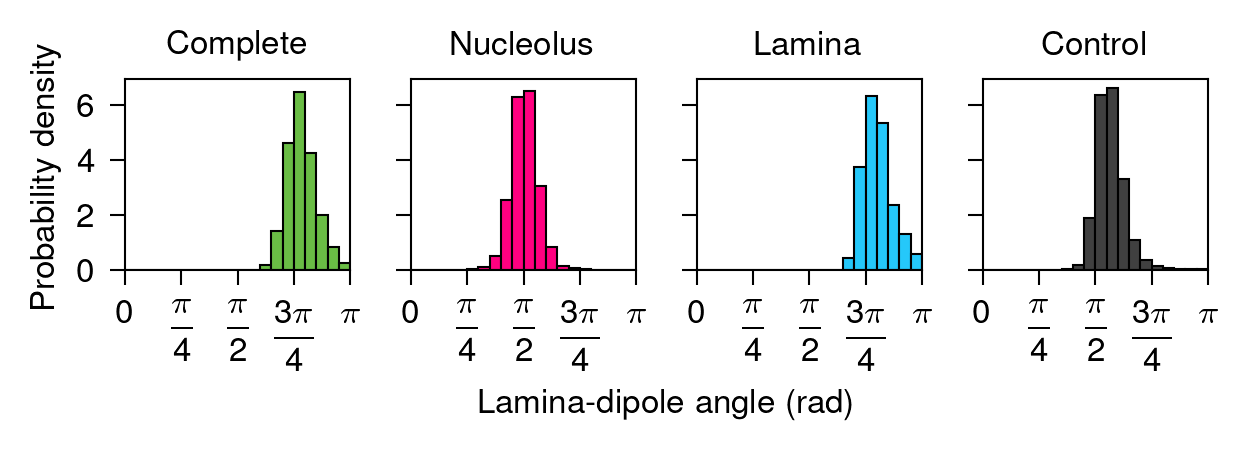

In [8]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=(4.2, 1.6),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

bins = np.linspace(0, 1, 21)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition.capitalize(), fontsize=8)

    ax[i].hist(
        polarization[condition]["dipole_alignment"] / np.pi,
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
    )

    ax[i].set_xlim((0, 1))
    ax[i].set_xticks(
        [0, 0.25, 0.50, 0.75, 1.0],
        [
            r"0",
            r"$\dfrac{\pi}{4}$",
            r"$\dfrac{\pi}{2}$",
            r"$\dfrac{3\pi}{4}$",
            r"$\pi$",
        ],
    )
    ax[i].set_yticks([0, 2, 4, 6])

ax[0].set_ylabel("Probability density")

fig.supxlabel(
    r"Lamina-dipole angle (rad)", y=0.11, x=0.535, fontsize=8
)

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

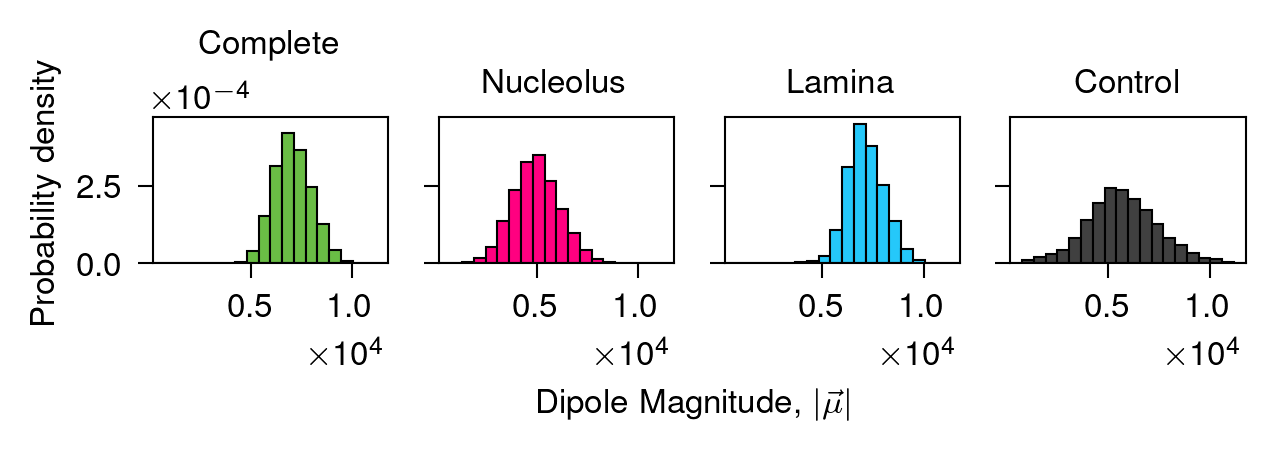

In [9]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=(4.2, 1.6),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

vmin = np.min(
    [
        np.min(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
vmax = np.max(
    [
        np.max(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
bins = np.linspace(vmin, vmax, 21)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition.capitalize(), fontsize=8)

    ax[i].hist(
        polarization[condition]["dipole_magnitude"],
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
    )

    # ax[i].set_xlim((0, 1))
    # ax[i].set_xticks(
    #     [0, 0.25, 0.50, 0.75, 1.0],
    #     [
    #         r"0",
    #         r"$\dfrac{\pi}{4}$",
    #         r"$\dfrac{\pi}{2}$",
    #         r"$\dfrac{3\pi}{4}$",
    #         r"$\pi$",
    #     ],
    # )
    # ax[i].set_yticks([0, 2, 4, 6])

ax[0].set_ylabel("Probability density")

fig.supxlabel(
    r"Dipole Magnitude, $|\vec{\mu}|$", y=0.11, x=0.535, fontsize=8
)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax[0].yaxis.set_major_formatter(formatter)
ax[0].set_xlim(vmin, vmax)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax[0].xaxis.set_major_formatter(formatter)


fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

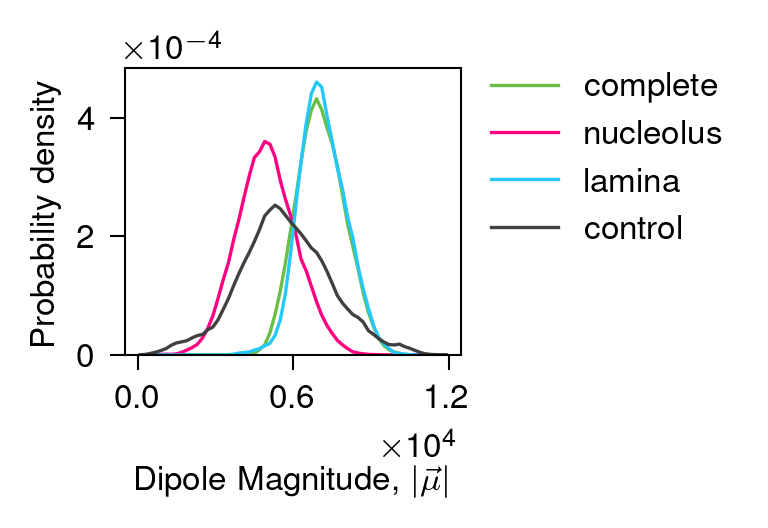

In [10]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(2.6, 1.8),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

vmin = np.min(
    [
        np.min(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
vmax = np.max(
    [
        np.max(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
bins = np.linspace(0, 1.2e4, 61)

for i, condition in enumerate(conditions):
    hist, bin_edges = np.histogram(
        polarization[condition]["dipole_magnitude"],
        bins=bins,
        density=True,
    )

    ax.plot(
        (bins[:-1] + bins[1:]) / 2,
        hist,
        label=condition,
        color=color_palette[condition],
    )

ax.set_xticks(
    [0, 6e3, 1.2e4], ["0", r"$6 \times 10^3$", r"$1.2 \times 10^4$"]
)
ax.set_ylim(bottom=0)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)

formatter = mpl.ticker.ScalarFormatter(
    useMathText=True, useOffset=False
)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.xaxis.set_major_formatter(formatter)

ax.set_ylabel("Probability density")
ax.set_xlabel(r"Dipole Magnitude, $|\vec{\mu}|$", labelpad=12)

ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.09))

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

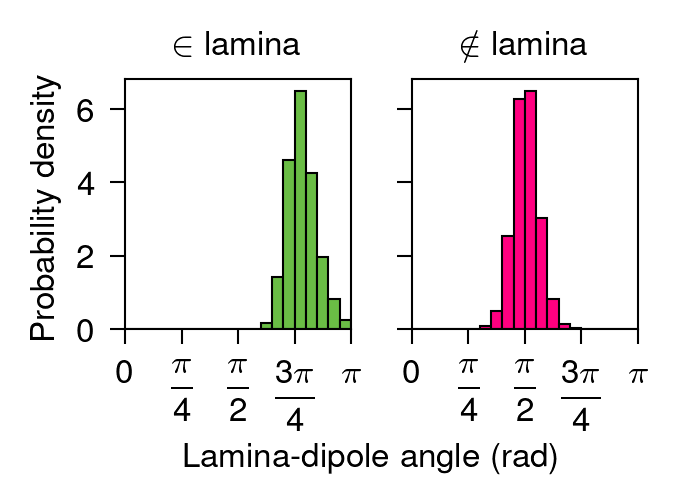

In [11]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(2.3, 1.8),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

bins = np.linspace(0, 1, 21)

for i, condition in enumerate(["complete", "nucleolus"]):
    ax[i].set_title(title[condition], fontsize=8)

    ax[i].hist(
        polarization[condition]["dipole_alignment"] / np.pi,
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
    )

    ax[i].set_xlim((0, 1))
    ax[i].set_xticks(
        [0, 0.25, 0.50, 0.75, 1.0],
        [
            r"0",
            r"$\dfrac{\pi}{4}$",
            r"$\dfrac{\pi}{2}$",
            r"$\dfrac{3\pi}{4}$",
            r"$\pi$",
        ],
    )
    ax[i].set_yticks([0, 2, 4, 6])

ax[0].set_ylabel("Probability density")

fig.supxlabel(
    r"Lamina-dipole angle (rad)", y=0.11, x=0.55, fontsize=8
)

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

## chr17


In [10]:
conditions = ["complete", "nucleolus", "lamina", "control"]

NUM_REPLICAS = 32
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

chromosome = 17

folder_num = 4 if chromosome == 1 else 5

OUTPUT_FOLDER = f"/scratch/mm146/Polarization/{folder_num}_IMR-90_hg38_chr{chromosome}/4_analysis/polarization/data"

In [11]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [12]:
color_palette

{'complete': '#6abd45',
 'control': '#404040',
 'lamina': '#25C8FA',
 'nucleolus': '#ff0080'}

In [13]:
title = {
    "complete": r"$\in\,\text{lamina}$",
    "nucleolus": r"$\notin\,\text{lamina}$",
}

In [14]:
# for testing the figures:
mpl.rcParams["figure.dpi"] = 300

### Concatenating the data


In [15]:
polarization = {}
for condition in conditions:
    polarization[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        print(f"Processing condition {condition}: replica {replica}")
        with h5py.File(
            os.path.join(
                OUTPUT_FOLDER,
                condition,
                f"polarization-replica{replica}.h5",
            )
        ) as saved_file:
            for key in saved_file.keys():
                if key not in polarization[condition].keys():
                    polarization[condition][key] = []
                polarization[condition][key].append(
                    saved_file[key][:]
                )

    for key in polarization[condition].keys():
        polarization[condition][key] = np.concatenate(
            polarization[condition][key], axis=0
        )

Processing condition complete: replica 1
Processing condition complete: replica 2
Processing condition complete: replica 3
Processing condition complete: replica 4
Processing condition complete: replica 5
Processing condition complete: replica 6
Processing condition complete: replica 7
Processing condition complete: replica 8
Processing condition complete: replica 9
Processing condition complete: replica 10
Processing condition complete: replica 11
Processing condition complete: replica 12
Processing condition complete: replica 13


Processing condition complete: replica 14
Processing condition complete: replica 15
Processing condition complete: replica 16
Processing condition complete: replica 17
Processing condition complete: replica 18
Processing condition complete: replica 19
Processing condition complete: replica 20
Processing condition complete: replica 21
Processing condition complete: replica 22
Processing condition complete: replica 23
Processing condition complete: replica 24
Processing condition complete: replica 25
Processing condition complete: replica 26
Processing condition complete: replica 27
Processing condition complete: replica 28
Processing condition complete: replica 29
Processing condition complete: replica 30
Processing condition complete: replica 31
Processing condition complete: replica 32
Processing condition nucleolus: replica 1
Processing condition nucleolus: replica 2
Processing condition nucleolus: replica 3
Processing condition nucleolus: replica 4
Processing condition nucleolus: re

In [16]:
with h5py.File(
    os.path.join(
        OUTPUT_FOLDER,
        f"polarization-data-aggregated.h5",
    ),
    "w",
) as saving_file:
    for condition in conditions:
        group = saving_file.create_group(condition)
        for key in polarization[condition].keys():
            group.create_dataset(
                f"{key}",
                data=polarization[condition][key],
            )

### Plotting


In [17]:
polarization = {}
with h5py.File(
    os.path.join(
        OUTPUT_FOLDER,
        f"polarization-data-aggregated.h5",
    ),
    "r",
) as saved_file:
    for condition in saved_file.keys():
        polarization[condition] = {}
        group = saved_file[condition]
        for key in group.keys():
            polarization[condition][key] = group[key][:]

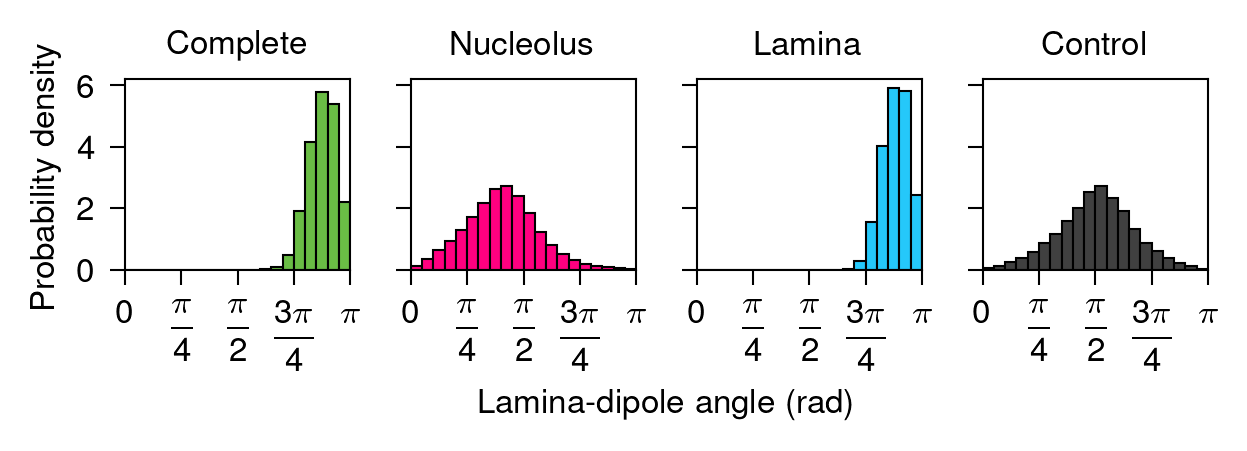

In [18]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=(4.2, 1.6),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

bins = np.linspace(0, 1, 21)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition.capitalize(), fontsize=8)

    ax[i].hist(
        polarization[condition]["dipole_alignment"] / np.pi,
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
    )

    ax[i].set_xlim((0, 1))
    ax[i].set_xticks(
        [0, 0.25, 0.50, 0.75, 1.0],
        [
            r"0",
            r"$\dfrac{\pi}{4}$",
            r"$\dfrac{\pi}{2}$",
            r"$\dfrac{3\pi}{4}$",
            r"$\pi$",
        ],
    )
    ax[i].set_yticks([0, 2, 4, 6])

ax[0].set_ylabel("Probability density")

fig.supxlabel(
    r"Lamina-dipole angle (rad)", y=0.11, x=0.535, fontsize=8
)

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

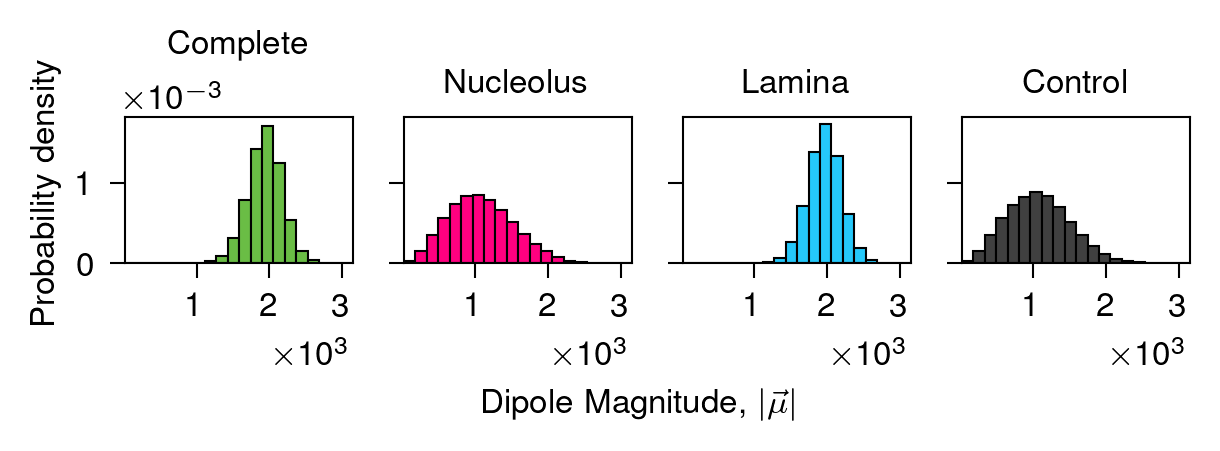

In [19]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=(4.2, 1.6),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

vmin = np.min(
    [
        np.min(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
vmax = np.max(
    [
        np.max(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
bins = np.linspace(vmin, vmax, 21)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition.capitalize(), fontsize=8)

    ax[i].hist(
        polarization[condition]["dipole_magnitude"],
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
    )

    # ax[i].set_xlim((0, 1))
    # ax[i].set_xticks(
    #     [0, 0.25, 0.50, 0.75, 1.0],
    #     [
    #         r"0",
    #         r"$\dfrac{\pi}{4}$",
    #         r"$\dfrac{\pi}{2}$",
    #         r"$\dfrac{3\pi}{4}$",
    #         r"$\pi$",
    #     ],
    # )
    # ax[i].set_yticks([0, 2, 4, 6])

ax[0].set_ylabel("Probability density")

fig.supxlabel(
    r"Dipole Magnitude, $|\vec{\mu}|$", y=0.11, x=0.535, fontsize=8
)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax[0].yaxis.set_major_formatter(formatter)
ax[0].set_xlim(vmin, vmax)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax[0].xaxis.set_major_formatter(formatter)


fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

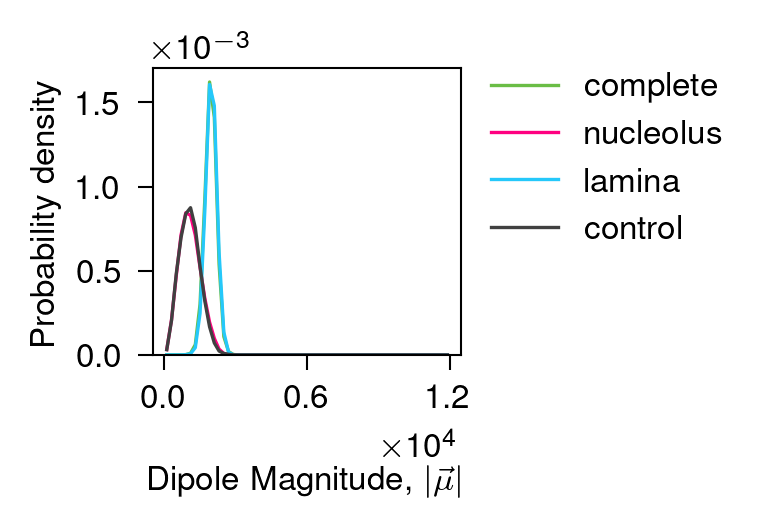

In [20]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(2.6, 1.8),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

vmin = np.min(
    [
        np.min(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
vmax = np.max(
    [
        np.max(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
bins = np.linspace(0, 1.2e4, 61)

for i, condition in enumerate(conditions):
    hist, bin_edges = np.histogram(
        polarization[condition]["dipole_magnitude"],
        bins=bins,
        density=True,
    )

    ax.plot(
        (bins[:-1] + bins[1:]) / 2,
        hist,
        label=condition,
        color=color_palette[condition],
    )

ax.set_xticks(
    [0, 6e3, 1.2e4], ["0", r"$6 \times 10^3$", r"$1.2 \times 10^4$"]
)
ax.set_ylim(bottom=0)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)

formatter = mpl.ticker.ScalarFormatter(
    useMathText=True, useOffset=False
)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.xaxis.set_major_formatter(formatter)

ax.set_ylabel("Probability density")
ax.set_xlabel(r"Dipole Magnitude, $|\vec{\mu}|$", labelpad=12)

ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.09))

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

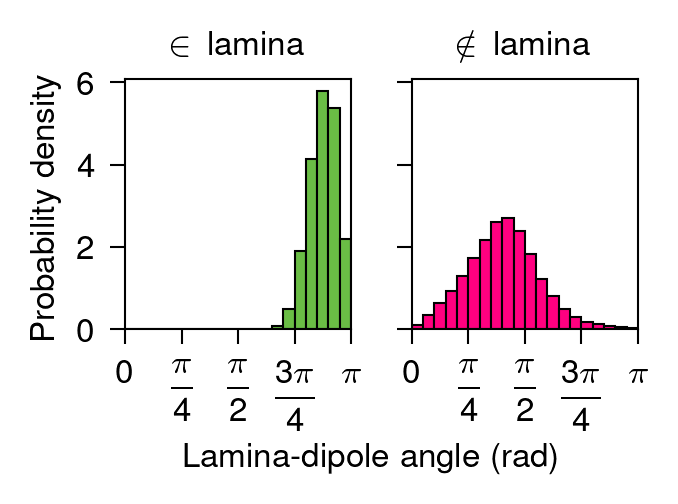

In [21]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(2.3, 1.8),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

bins = np.linspace(0, 1, 21)

for i, condition in enumerate(["complete", "nucleolus"]):
    ax[i].set_title(title[condition], fontsize=8)

    ax[i].hist(
        polarization[condition]["dipole_alignment"] / np.pi,
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
    )

    ax[i].set_xlim((0, 1))
    ax[i].set_xticks(
        [0, 0.25, 0.50, 0.75, 1.0],
        [
            r"0",
            r"$\dfrac{\pi}{4}$",
            r"$\dfrac{\pi}{2}$",
            r"$\dfrac{3\pi}{4}$",
            r"$\pi$",
        ],
    )
    ax[i].set_yticks([0, 2, 4, 6])

ax[0].set_ylabel("Probability density")

fig.supxlabel(
    r"Lamina-dipole angle (rad)", y=0.11, x=0.55, fontsize=8
)

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

# nuclear bodies as beads

## chr1


In [3]:
conditions = ["complete", "nucleolus"]

NUM_REPLICAS = 96
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

chromosome = 1

folder_num = 4 if chromosome == 1 else 5

OUTPUT_FOLDER = f"/scratch/mm146/Polarization/{folder_num}_IMR-90_hg38_chr{chromosome}/7_analysis/polarization/data"

In [4]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [5]:
color_palette

{'complete': '#6abd45',
 'control': '#404040',
 'lamina': '#25C8FA',
 'nucleolus': '#ff0080'}

In [6]:
title = {
    "complete": r"$\in\,\text{lamina}$",
    "nucleolus": r"$\notin\,\text{lamina}$",
}

In [7]:
# for testing the figures:
# mpl.rcParams["figure.dpi"] = 300

### Concatenating the data


In [7]:
polarization = {}
for condition in conditions:
    polarization[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        print(f"Processing condition {condition}: replica {replica}")
        with h5py.File(
            os.path.join(
                OUTPUT_FOLDER,
                condition,
                f"polarization-replica{replica}.h5",
            )
        ) as saved_file:
            for key in saved_file.keys():
                if key not in polarization[condition].keys():
                    polarization[condition][key] = []
                polarization[condition][key].append(
                    saved_file[key][:]
                )

    for key in polarization[condition].keys():
        polarization[condition][key] = np.concatenate(
            polarization[condition][key], axis=0
        )

Processing condition complete: replica 1
Processing condition complete: replica 2
Processing condition complete: replica 3
Processing condition complete: replica 4
Processing condition complete: replica 5
Processing condition complete: replica 6
Processing condition complete: replica 7
Processing condition complete: replica 8
Processing condition complete: replica 9
Processing condition complete: replica 10
Processing condition complete: replica 11
Processing condition complete: replica 12
Processing condition complete: replica 13
Processing condition complete: replica 14
Processing condition complete: replica 15
Processing condition complete: replica 16
Processing condition complete: replica 17
Processing condition complete: replica 18
Processing condition complete: replica 19
Processing condition complete: replica 20
Processing condition complete: replica 21
Processing condition complete: replica 22
Processing condition complete: replica 23
Processing condition complete: replica 24
P

In [8]:
with h5py.File(
    os.path.join(
        OUTPUT_FOLDER,
        f"polarization-data-aggregated.h5",
    ),
    "w",
) as saving_file:
    for condition in conditions:
        group = saving_file.create_group(condition)
        for key in polarization[condition].keys():
            group.create_dataset(
                f"{key}",
                data=polarization[condition][key],
            )

### Plotting


In [9]:
polarization = {}
with h5py.File(
    os.path.join(
        OUTPUT_FOLDER,
        f"polarization-data-aggregated.h5",
    ),
    "r",
) as saved_file:
    for condition in saved_file.keys():
        polarization[condition] = {}
        group = saved_file[condition]
        for key in group.keys():
            polarization[condition][key] = group[key][:]

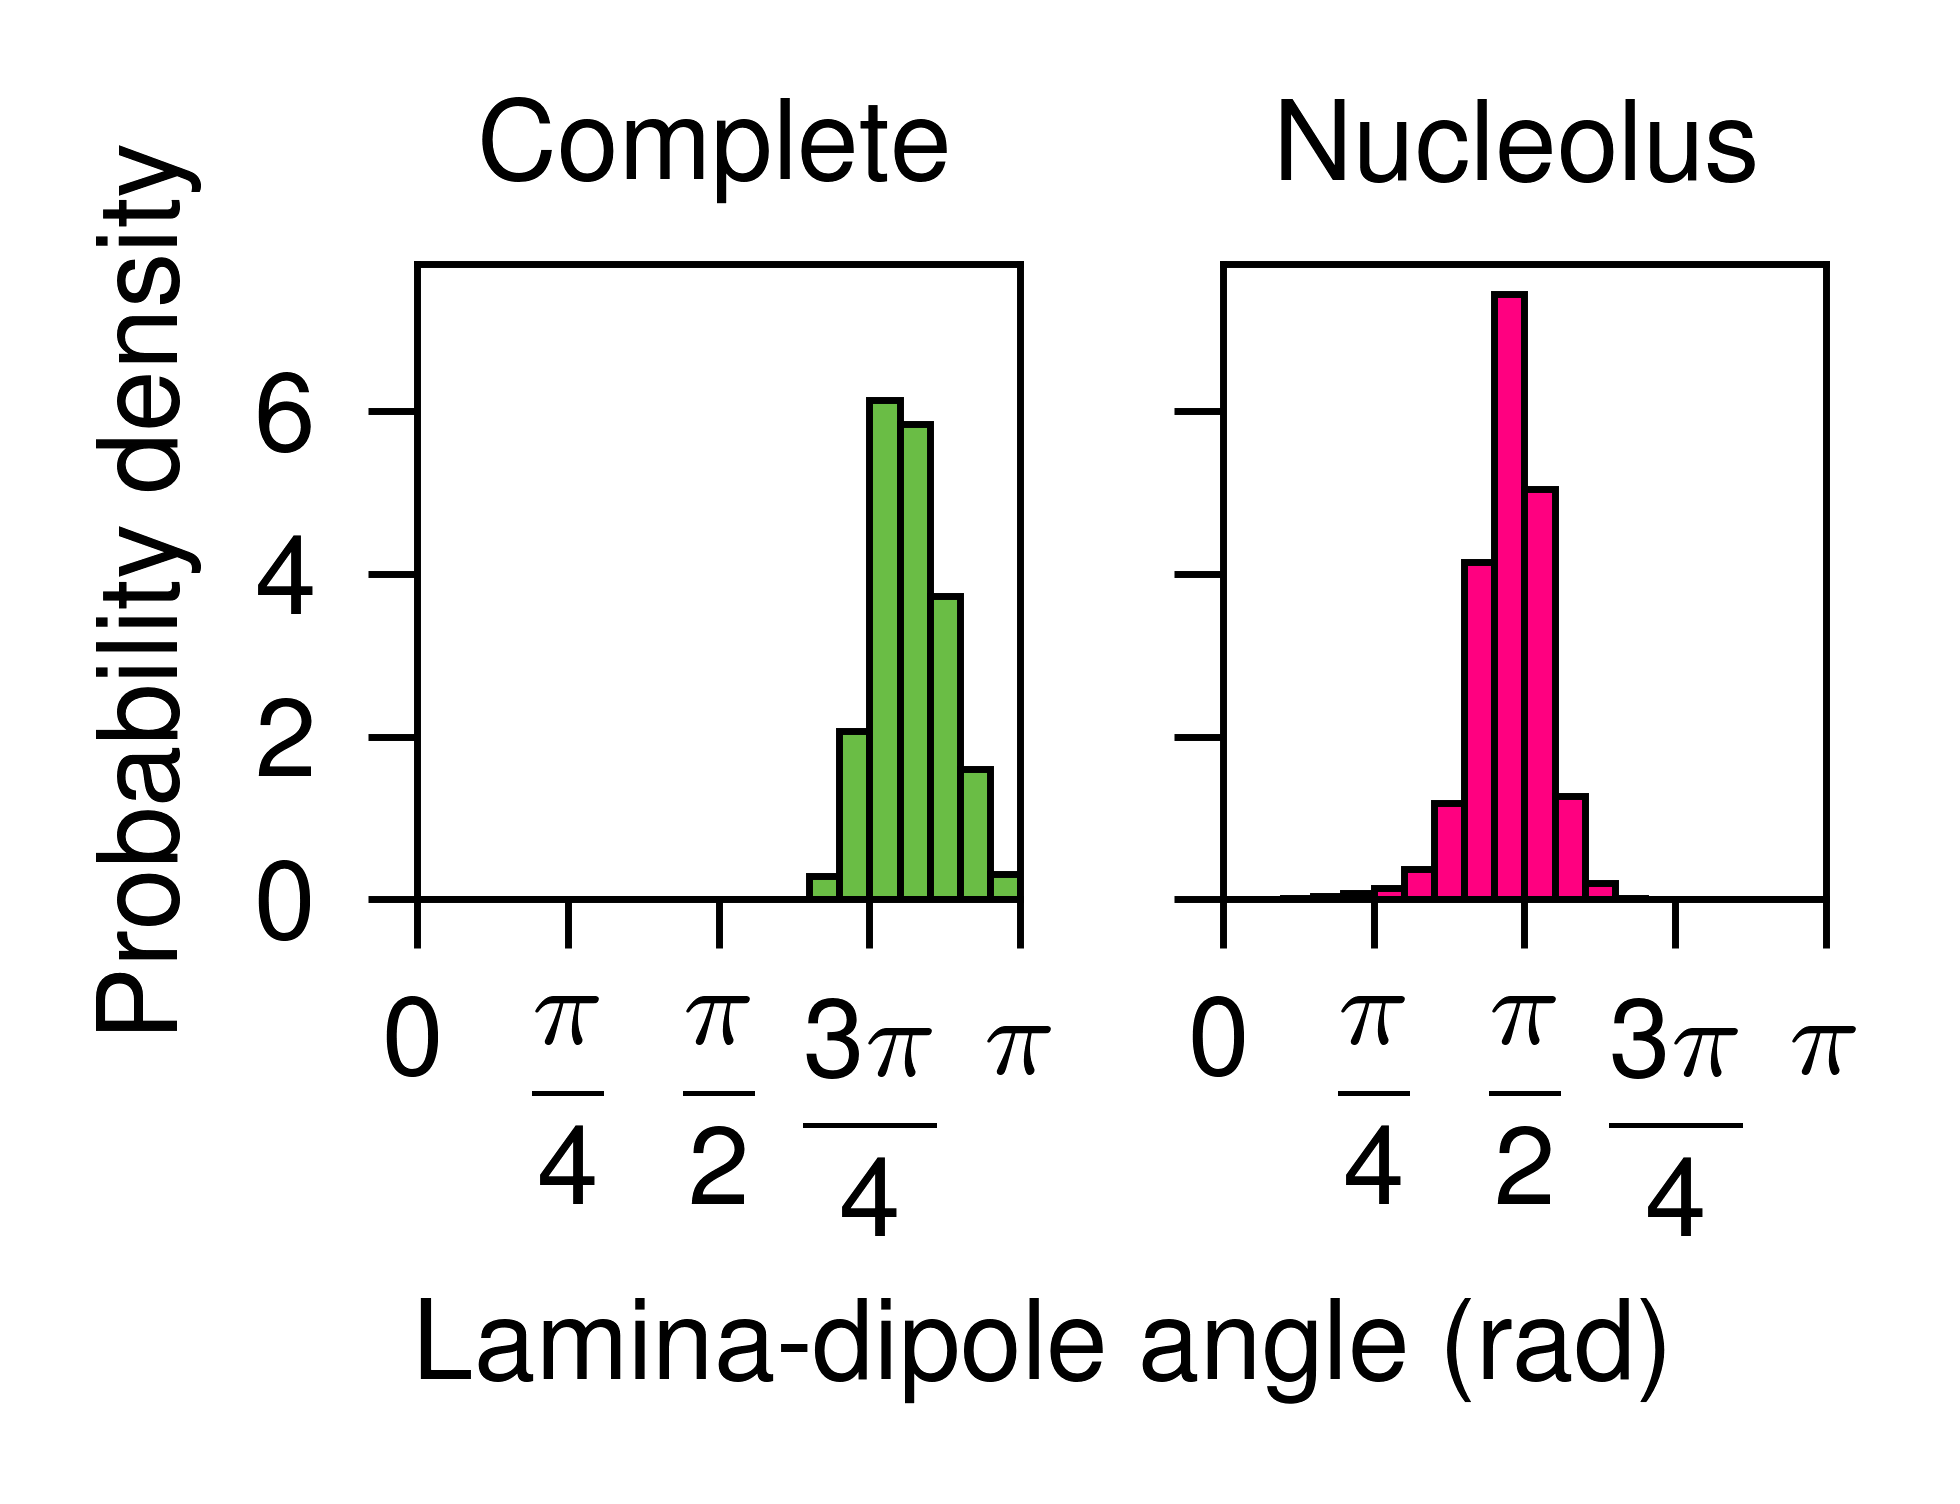

In [15]:
fig, ax = plt.subplots(
    1,
    len(conditions),
    figsize=(1*len(conditions), 1.6),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

bins = np.linspace(0, 1, 21)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition.capitalize(), fontsize=8)

    ax[i].hist(
        polarization[condition]["dipole_alignment"] / np.pi,
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
    )

    ax[i].set_xlim((0, 1))
    ax[i].set_xticks(
        [0, 0.25, 0.50, 0.75, 1.0],
        [
            r"0",
            r"$\dfrac{\pi}{4}$",
            r"$\dfrac{\pi}{2}$",
            r"$\dfrac{3\pi}{4}$",
            r"$\pi$",
        ],
    )
    ax[i].set_yticks([0, 2, 4, 6])

ax[0].set_ylabel("Probability density")

fig.supxlabel(
    r"Lamina-dipole angle (rad)", y=0.11, x=0.535, fontsize=8
)

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

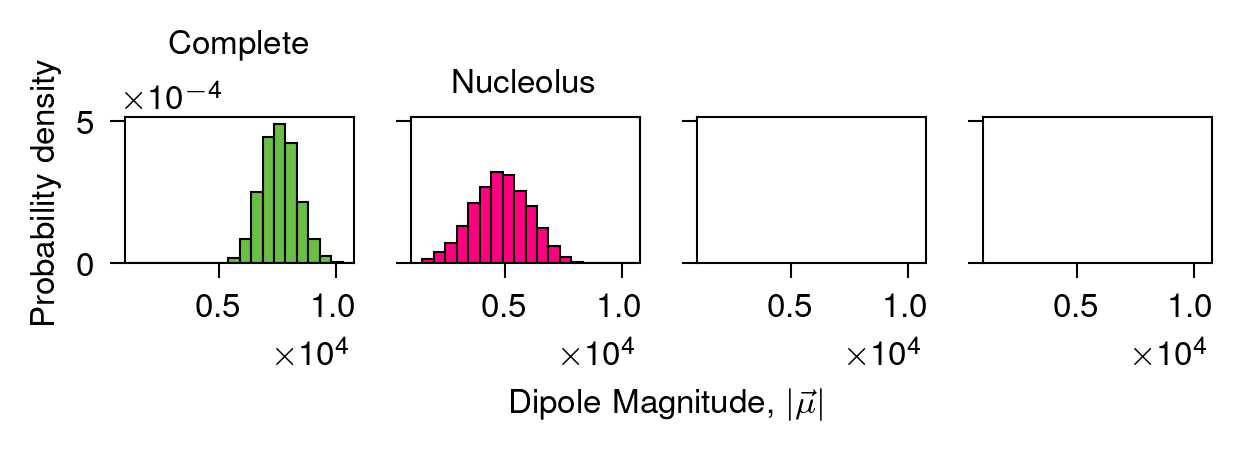

In [11]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=(4.2, 1.6),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

vmin = np.min(
    [
        np.min(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
vmax = np.max(
    [
        np.max(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
bins = np.linspace(vmin, vmax, 21)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition.capitalize(), fontsize=8)

    ax[i].hist(
        polarization[condition]["dipole_magnitude"],
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
    )

    # ax[i].set_xlim((0, 1))
    # ax[i].set_xticks(
    #     [0, 0.25, 0.50, 0.75, 1.0],
    #     [
    #         r"0",
    #         r"$\dfrac{\pi}{4}$",
    #         r"$\dfrac{\pi}{2}$",
    #         r"$\dfrac{3\pi}{4}$",
    #         r"$\pi$",
    #     ],
    # )
    # ax[i].set_yticks([0, 2, 4, 6])

ax[0].set_ylabel("Probability density")

fig.supxlabel(
    r"Dipole Magnitude, $|\vec{\mu}|$", y=0.11, x=0.535, fontsize=8
)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax[0].yaxis.set_major_formatter(formatter)
ax[0].set_xlim(vmin, vmax)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax[0].xaxis.set_major_formatter(formatter)


fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

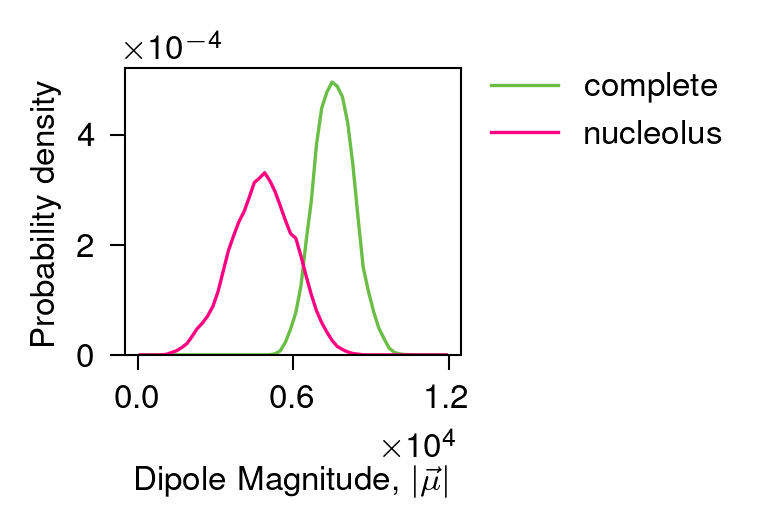

In [12]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(2.6, 1.8),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

vmin = np.min(
    [
        np.min(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
vmax = np.max(
    [
        np.max(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
bins = np.linspace(0, 1.2e4, 61)

for i, condition in enumerate(conditions):
    hist, bin_edges = np.histogram(
        polarization[condition]["dipole_magnitude"],
        bins=bins,
        density=True,
    )

    ax.plot(
        (bins[:-1] + bins[1:]) / 2,
        hist,
        label=condition,
        color=color_palette[condition],
    )

ax.set_xticks(
    [0, 6e3, 1.2e4], ["0", r"$6 \times 10^3$", r"$1.2 \times 10^4$"]
)
ax.set_ylim(bottom=0)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)

formatter = mpl.ticker.ScalarFormatter(
    useMathText=True, useOffset=False
)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.xaxis.set_major_formatter(formatter)

ax.set_ylabel("Probability density")
ax.set_xlabel(r"Dipole Magnitude, $|\vec{\mu}|$", labelpad=12)

ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.09))

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

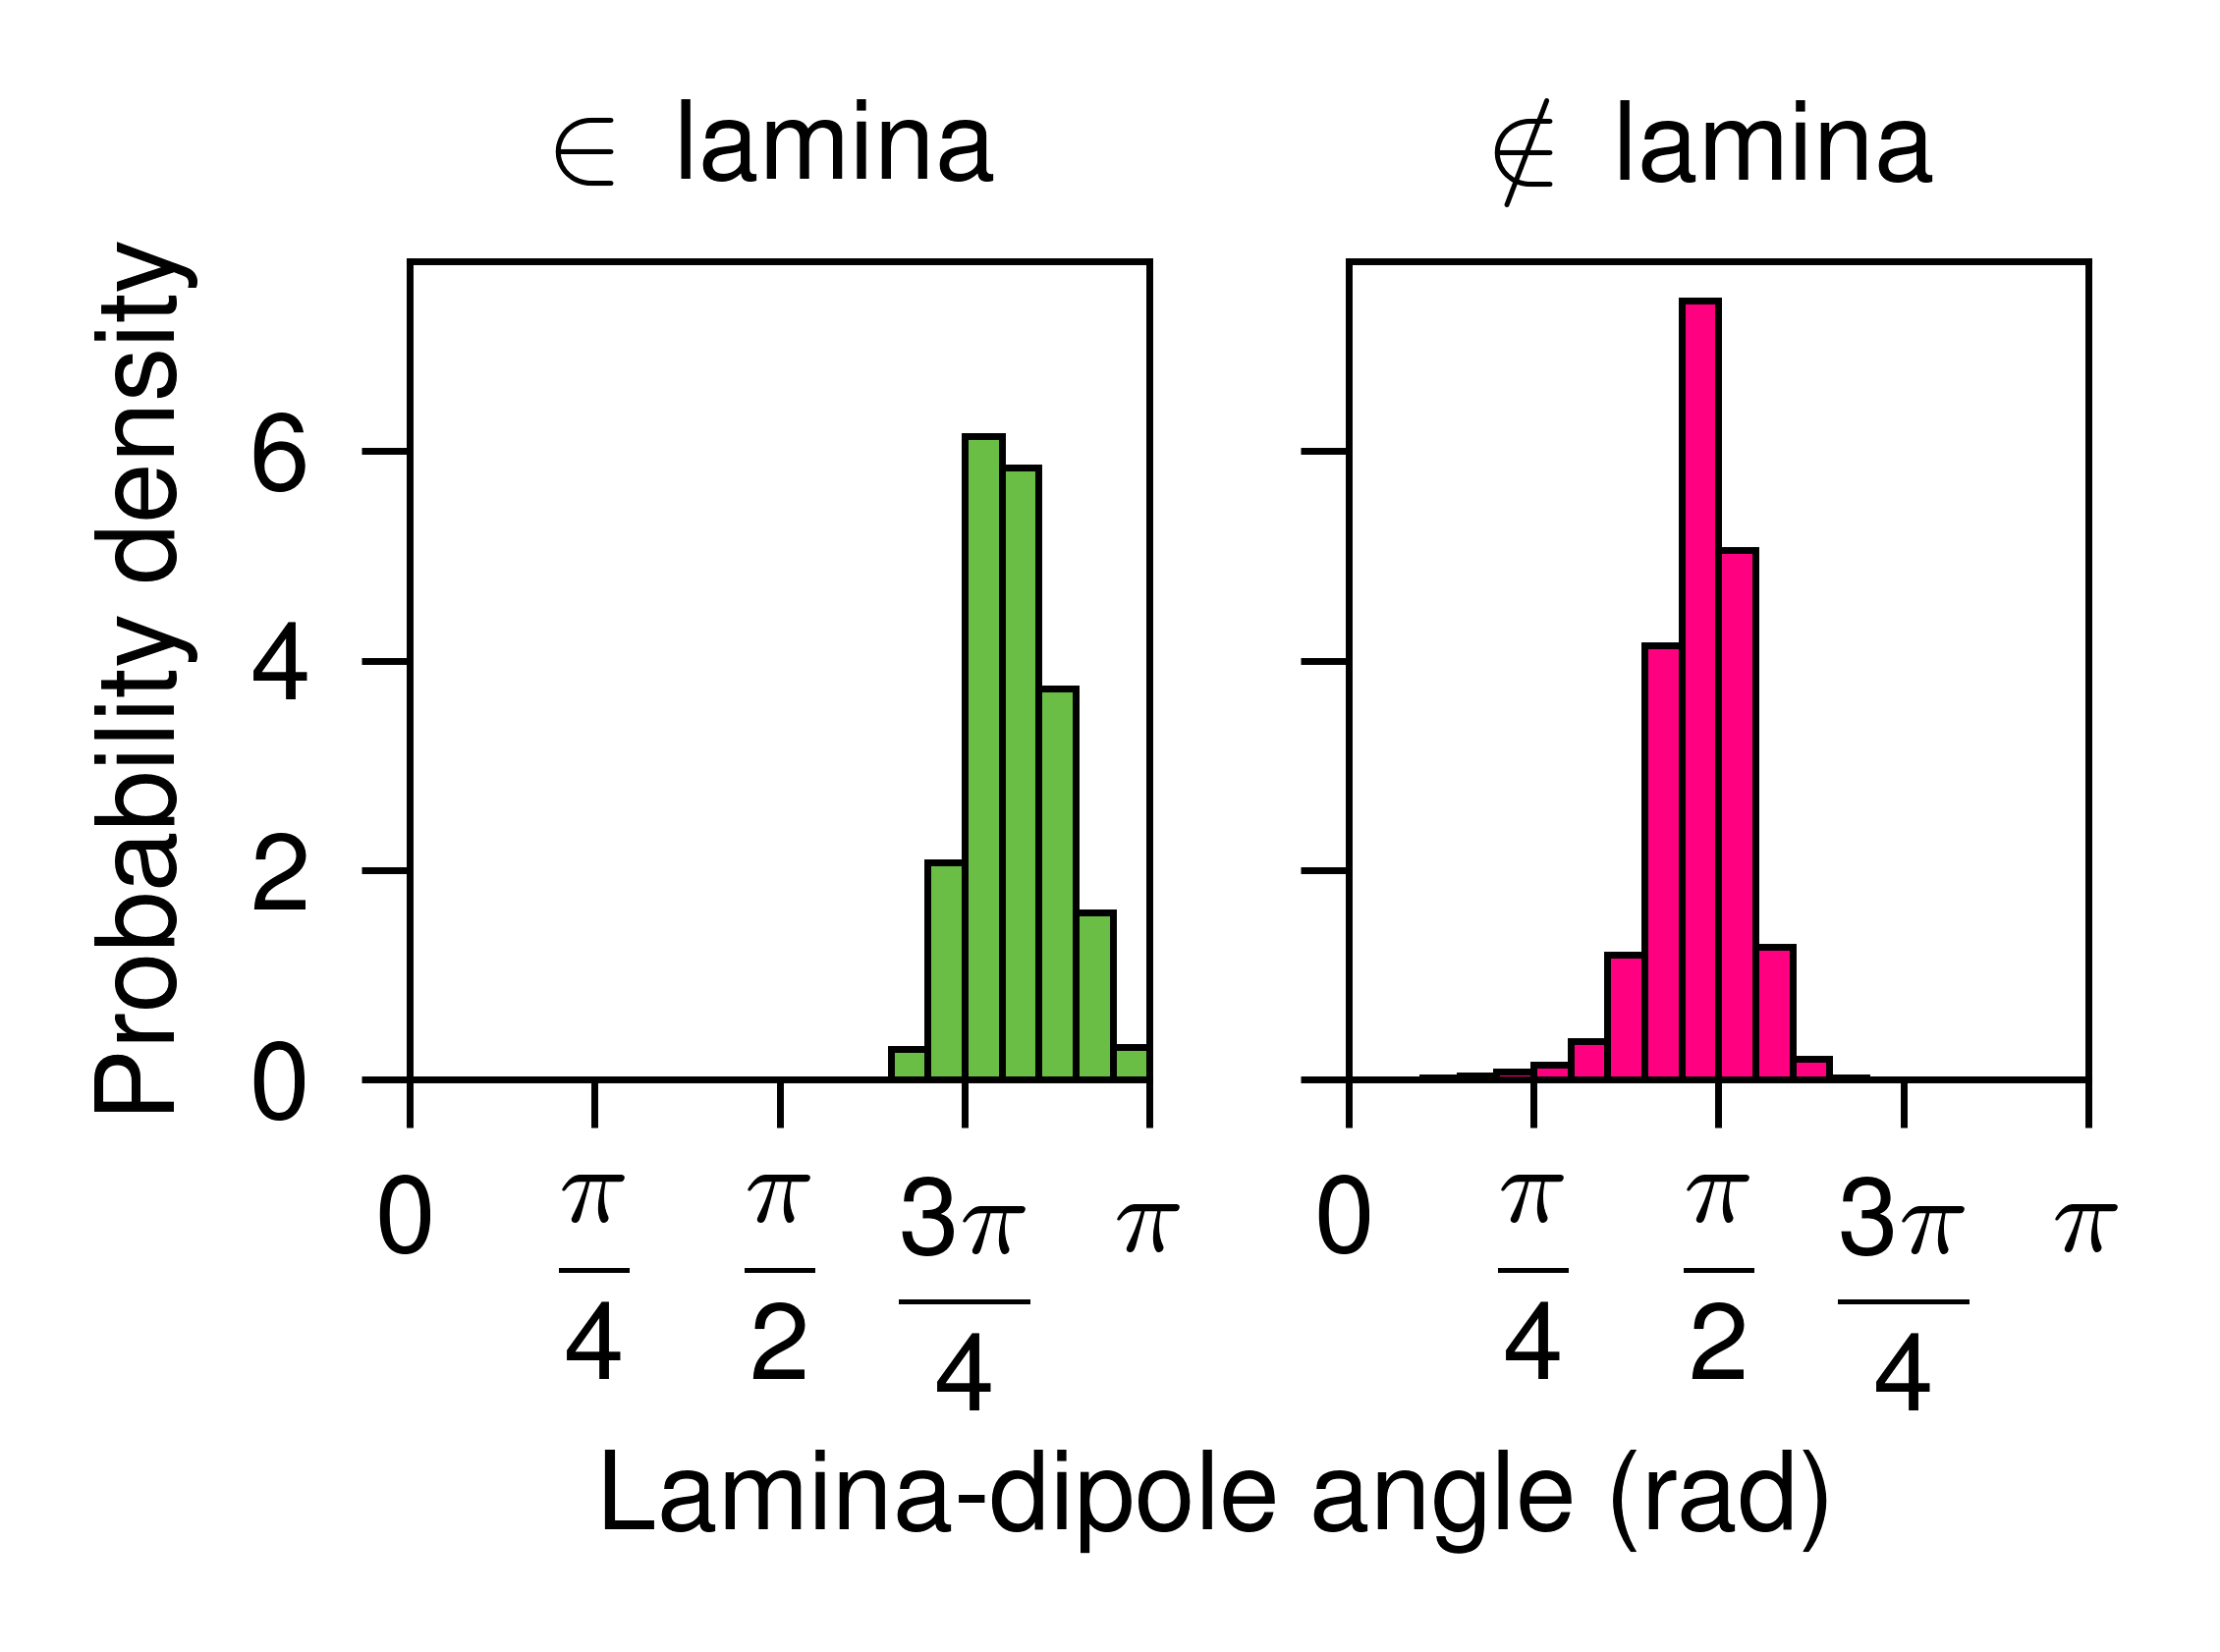

In [17]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(2.3, 1.8),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

bins = np.linspace(0, 1, 21)

for i, condition in enumerate(["complete", "nucleolus"]):
    ax[i].set_title(title[condition], fontsize=8)

    ax[i].hist(
        polarization[condition]["dipole_alignment"] / np.pi,
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
    )

    ax[i].set_xlim((0, 1))
    ax[i].set_xticks(
        [0, 0.25, 0.50, 0.75, 1.0],
        [
            r"0",
            r"$\dfrac{\pi}{4}$",
            r"$\dfrac{\pi}{2}$",
            r"$\dfrac{3\pi}{4}$",
            r"$\pi$",
        ],
    )
    ax[i].set_yticks([0, 2, 4, 6])

ax[0].set_ylabel("Probability density")

fig.supxlabel(
    r"Lamina-dipole angle (rad)", y=0.11, x=0.55, fontsize=8
)

fig.tight_layout()
fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

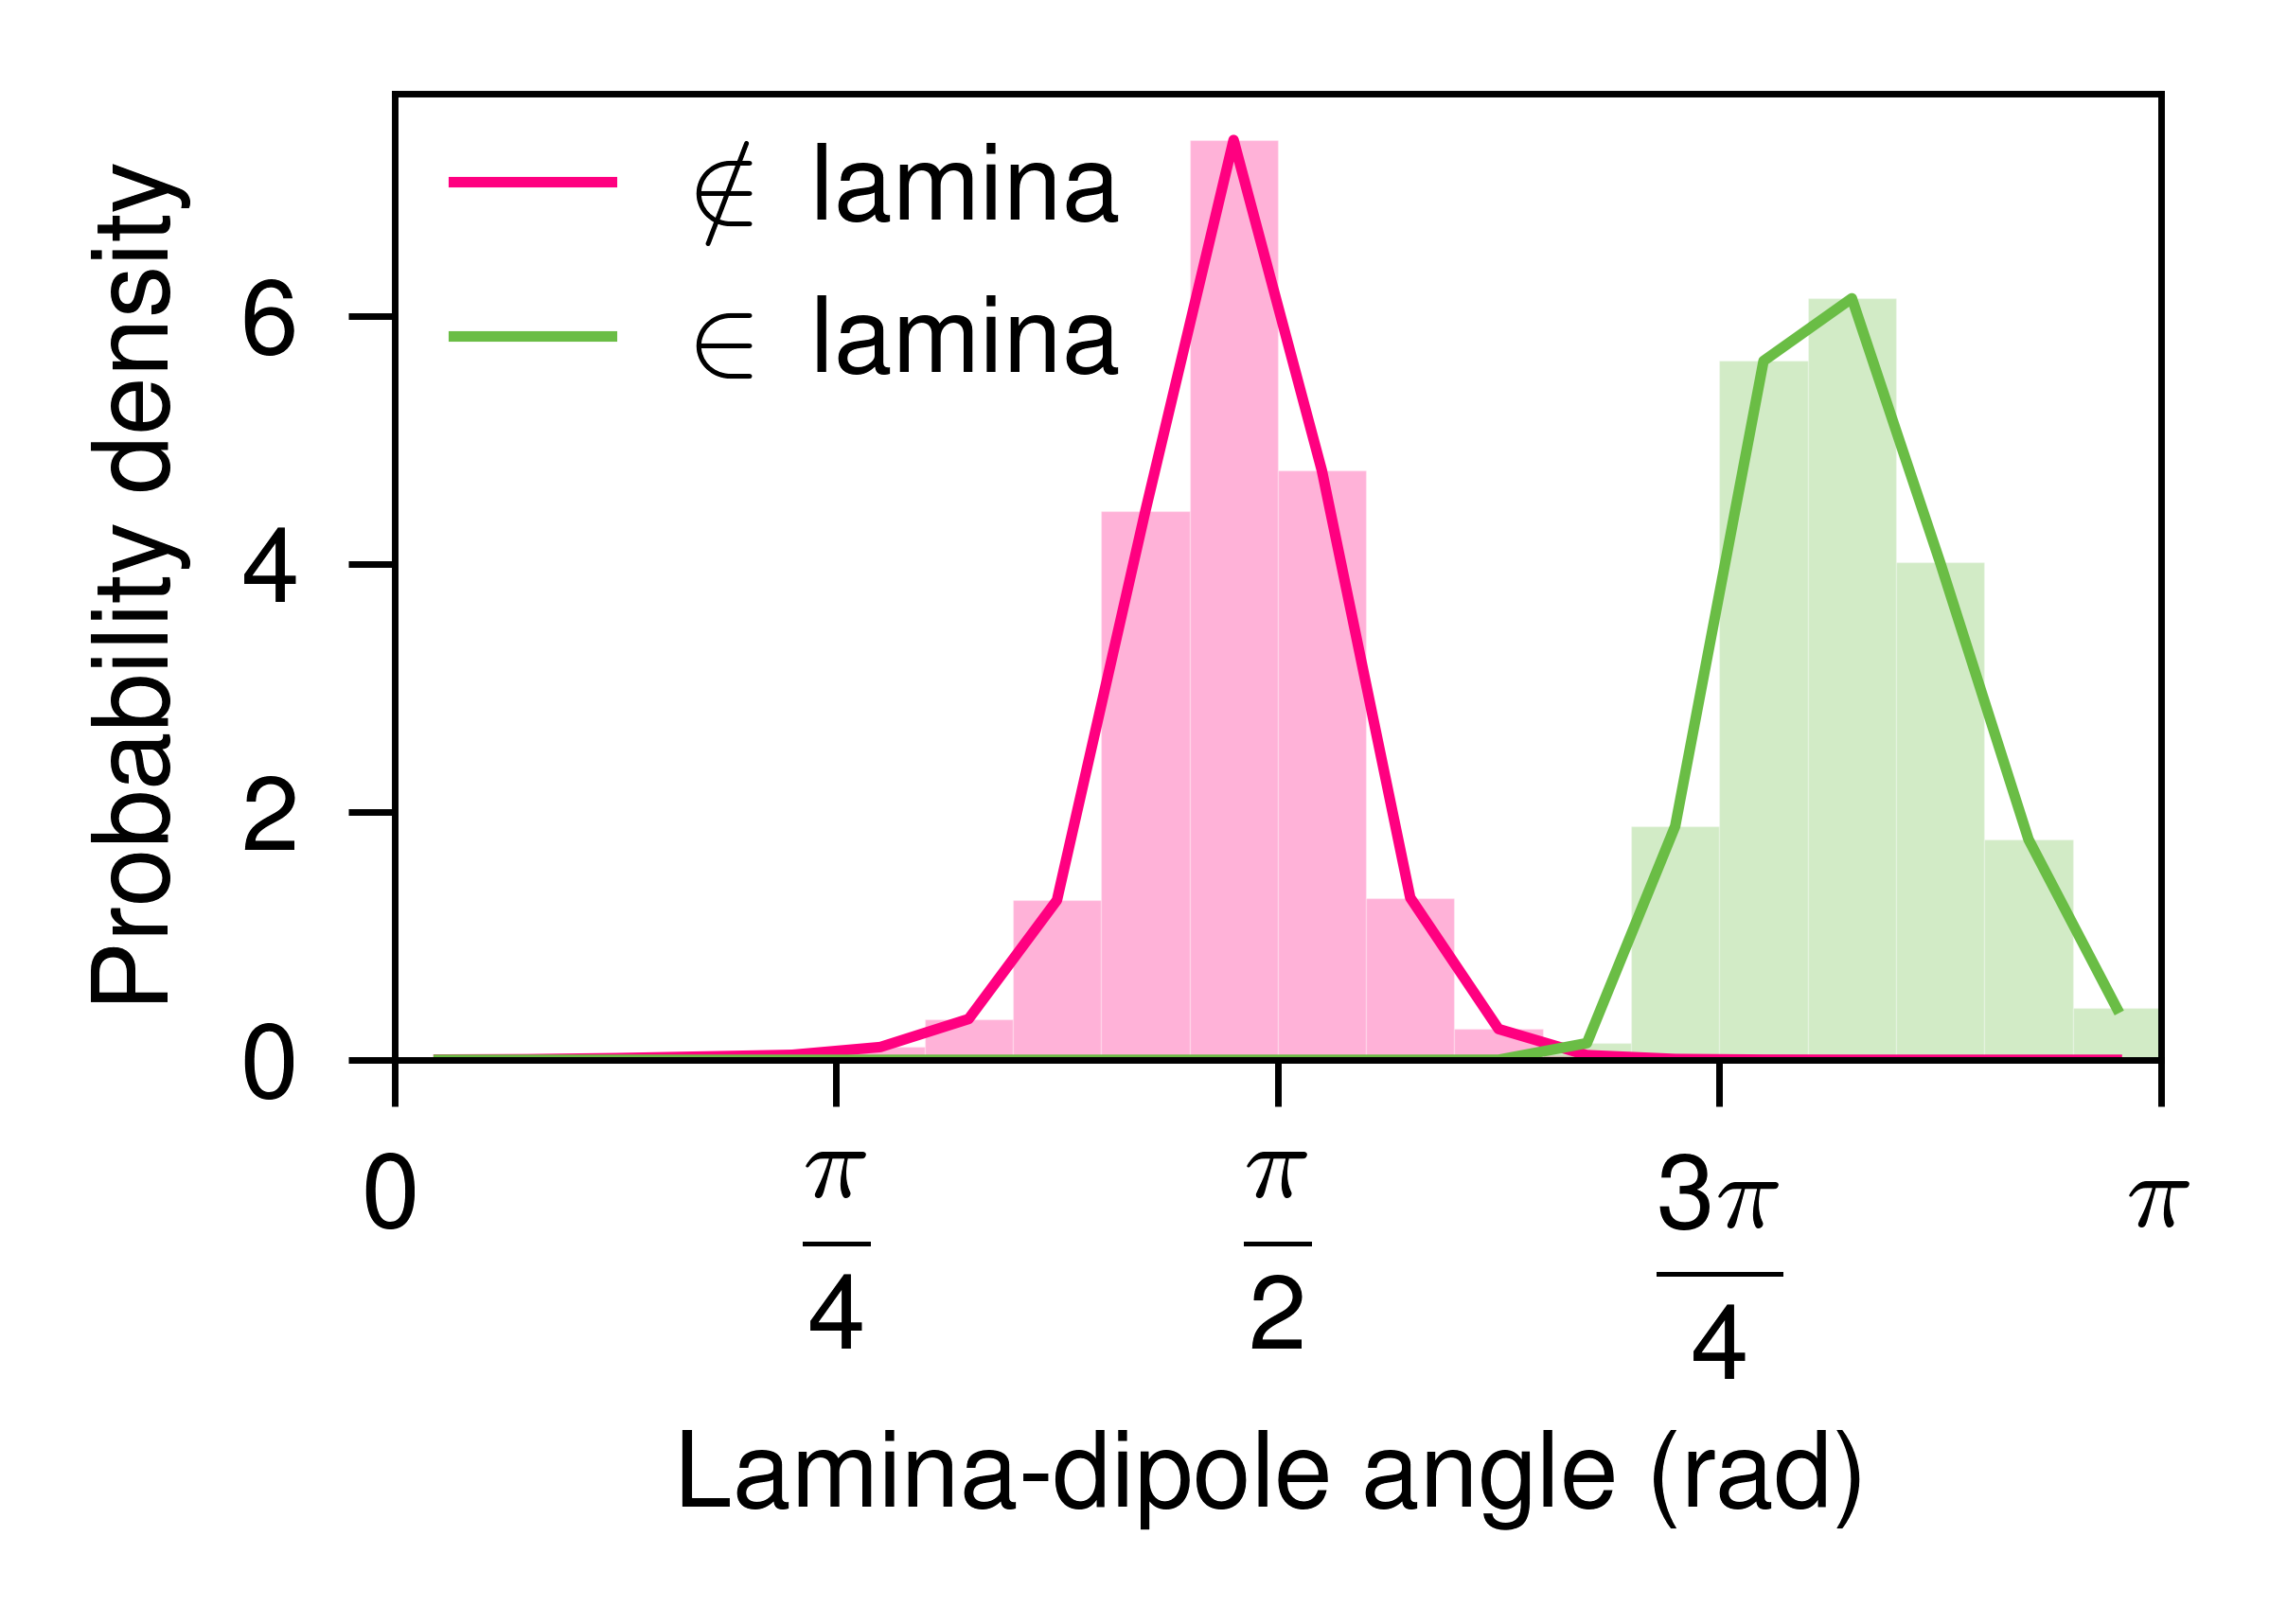

In [10]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(2.3, 1.6),
    layout="constrained",
)

nbins = 21
width = 1/(nbins - 1)

for condition in ["nucleolus", "complete"]:
    hist, bin_edges = np.histogram(
        polarization[condition]["dipole_alignment"] / np.pi,
        density=True,
        bins=np.linspace(0, 1, nbins),
    )

    xaxis = (bin_edges[1:] + bin_edges[:-1]) / 2

    ax.plot(
        xaxis,
        hist,
        color=color_palette[condition],
        label=title[condition],
    )
    ax.bar(
        xaxis,
        hist,
        width=width,
        color=color_palette[condition],
        alpha=0.30,
        edgecolor="white",
        linewidth=0.1,
    )

ax.set_xlabel(r"Lamina-dipole angle (rad)")
ax.set_ylabel("Probability density")
ax.set_xlim((0, 1))
ax.set_xticks(
    [0, 0.25, 0.50, 0.75, 1.0],
    [
        r"0",
        r"$\dfrac{\pi}{4}$",
        r"$\dfrac{\pi}{2}$",
        r"$\dfrac{3\pi}{4}$",
        r"$\pi$",
    ],
)
ax.set_yticks([0, 2, 4, 6])

ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(-0.02, 1.05), handlelength=1.5)

fig.savefig("figures/fig-dipole-alignment-one-panel.pdf")

/tmp/ipykernel_4073556/3030744910.py:23: RuntimeWarning: divide by zero encountered in divide
  np.log(hist["nucleolus"]/hist["complete"]),
/tmp/ipykernel_4073556/3030744910.py:23: RuntimeWarning: divide by zero encountered in log
  np.log(hist["nucleolus"]/hist["complete"]),


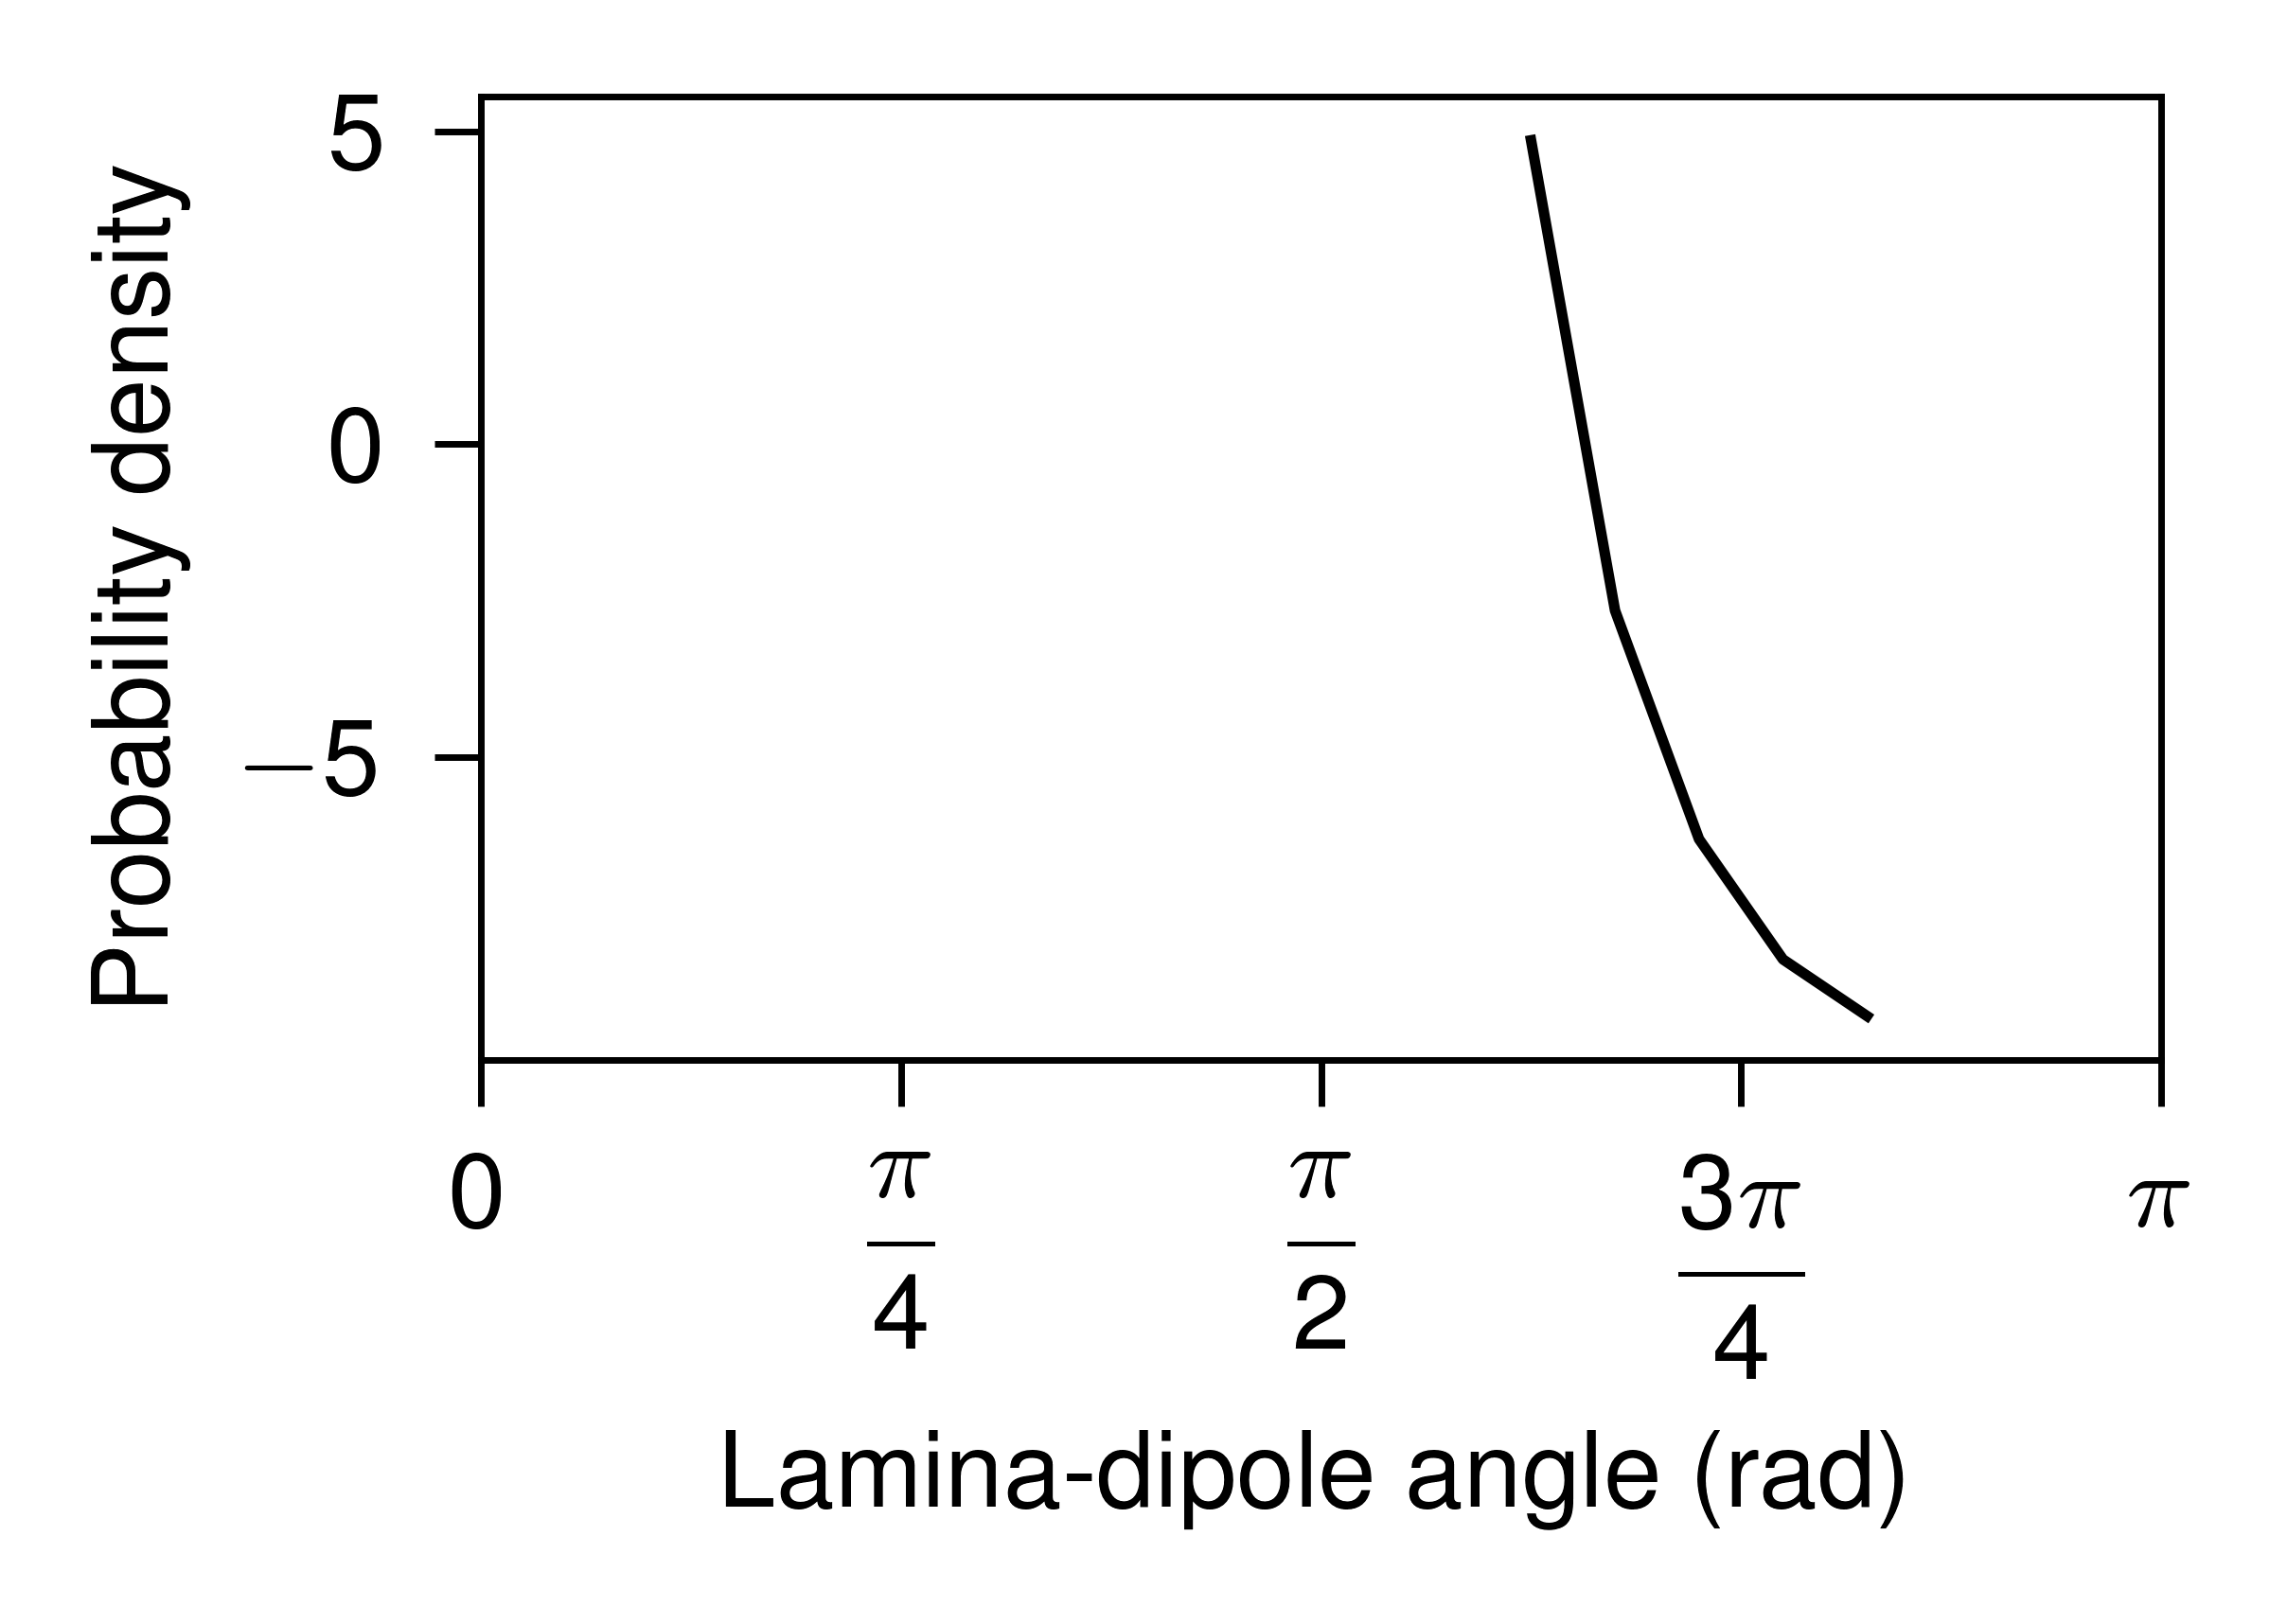

In [9]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(2.3, 1.6),
    layout="constrained",
)

nbins = 21
width = 1/(nbins - 1)

hist = {}
for condition in ["nucleolus", "complete"]:
    hist[condition], bin_edges = np.histogram(
        polarization[condition]["dipole_alignment"] / np.pi,
        density=True,
        bins=np.linspace(0, 1, nbins),
    )

    xaxis = (bin_edges[1:] + bin_edges[:-1]) / 2

ax.plot(
    xaxis,
    np.log(hist["nucleolus"]/hist["complete"]),
    color="black",
)


ax.set_xlabel(r"Lamina-dipole angle (rad)")
ax.set_ylabel("Probability density")
ax.set_xlim((0, 1))
ax.set_xticks(
    [0, 0.25, 0.50, 0.75, 1.0],
    [
        r"0",
        r"$\dfrac{\pi}{4}$",
        r"$\dfrac{\pi}{2}$",
        r"$\dfrac{3\pi}{4}$",
        r"$\pi$",
    ],
)
# ax.set_yticks([0, 2, 4, 6])

# ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(-0.02, 1.05), handlelength=1.5)

# fig.savefig("figures/fig-dipole-alignment-one-panel.pdf")

## chr1 - ∆lam = 1.5 and undivided

In [14]:
conditions = ["complete", "nucleolus"]

NUM_REPLICAS = 32
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

chromosome = 1

folder_num = 4 if chromosome == 1 else 5

OUTPUT_FOLDER = f"/scratch/mm146/Polarization/{folder_num}_IMR-90_hg38_chr{chromosome}/9_analysis/polarization/data"

In [15]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [16]:
color_palette

{'complete': '#6abd45',
 'control': '#404040',
 'lamina': '#25C8FA',
 'nucleolus': '#ff0080'}

In [17]:
title = {
    "complete": r"$\in\,\text{lamina}$",
    "nucleolus": r"$\notin\,\text{lamina}$",
}

In [18]:
# for testing the figures:
mpl.rcParams["figure.dpi"] = 300

### Concatenating the data


In [19]:
polarization = {}
for condition in conditions:
    polarization[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        print(f"Processing condition {condition}: replica {replica}")
        with h5py.File(
            os.path.join(
                OUTPUT_FOLDER,
                condition,
                f"polarization-replica{replica}.h5",
            )
        ) as saved_file:
            for key in saved_file.keys():
                if key not in polarization[condition].keys():
                    polarization[condition][key] = []
                polarization[condition][key].append(
                    saved_file[key][:]
                )

    for key in polarization[condition].keys():
        polarization[condition][key] = np.concatenate(
            polarization[condition][key], axis=0
        )

Processing condition complete: replica 1
Processing condition complete: replica 2
Processing condition complete: replica 3
Processing condition complete: replica 4
Processing condition complete: replica 5
Processing condition complete: replica 6
Processing condition complete: replica 7
Processing condition complete: replica 8
Processing condition complete: replica 9
Processing condition complete: replica 10
Processing condition complete: replica 11
Processing condition complete: replica 12
Processing condition complete: replica 13
Processing condition complete: replica 14
Processing condition complete: replica 15
Processing condition complete: replica 16
Processing condition complete: replica 17
Processing condition complete: replica 18
Processing condition complete: replica 19
Processing condition complete: replica 20
Processing condition complete: replica 21
Processing condition complete: replica 22
Processing condition complete: replica 23
Processing condition complete: replica 24
P

In [20]:
with h5py.File(
    os.path.join(
        OUTPUT_FOLDER,
        f"polarization-data-aggregated.h5",
    ),
    "w",
) as saving_file:
    for condition in conditions:
        group = saving_file.create_group(condition)
        for key in polarization[condition].keys():
            group.create_dataset(
                f"{key}",
                data=polarization[condition][key],
            )

### Plotting


In [21]:
polarization = {}
with h5py.File(
    os.path.join(
        OUTPUT_FOLDER,
        f"polarization-data-aggregated.h5",
    ),
    "r",
) as saved_file:
    for condition in saved_file.keys():
        polarization[condition] = {}
        group = saved_file[condition]
        for key in group.keys():
            polarization[condition][key] = group[key][:]

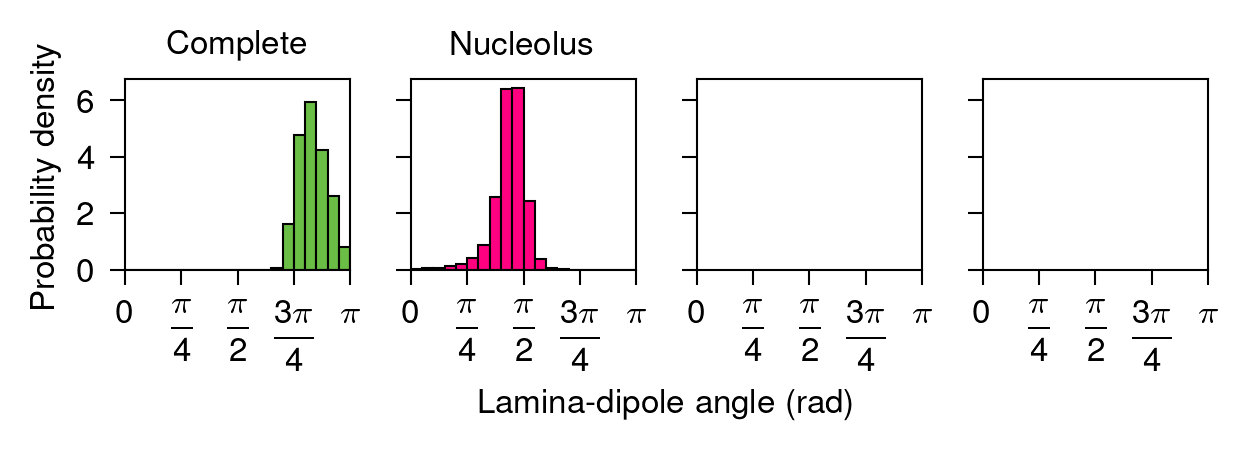

In [22]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=(4.2, 1.6),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

bins = np.linspace(0, 1, 21)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition.capitalize(), fontsize=8)

    ax[i].hist(
        polarization[condition]["dipole_alignment"] / np.pi,
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
    )

    ax[i].set_xlim((0, 1))
    ax[i].set_xticks(
        [0, 0.25, 0.50, 0.75, 1.0],
        [
            r"0",
            r"$\dfrac{\pi}{4}$",
            r"$\dfrac{\pi}{2}$",
            r"$\dfrac{3\pi}{4}$",
            r"$\pi$",
        ],
    )
    ax[i].set_yticks([0, 2, 4, 6])

ax[0].set_ylabel("Probability density")

fig.supxlabel(
    r"Lamina-dipole angle (rad)", y=0.11, x=0.535, fontsize=8
)

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

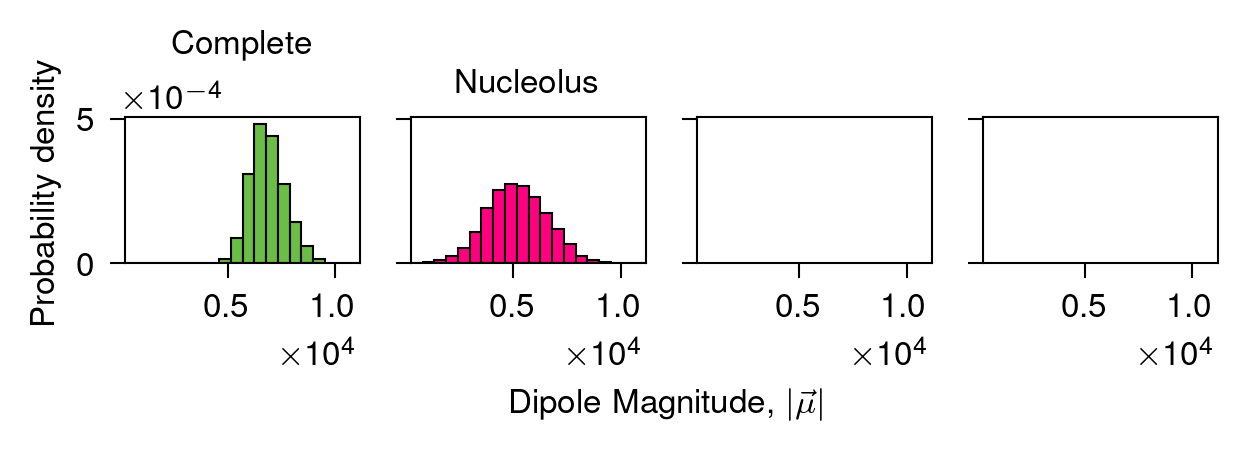

In [23]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=(4.2, 1.6),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

vmin = np.min(
    [
        np.min(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
vmax = np.max(
    [
        np.max(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
bins = np.linspace(vmin, vmax, 21)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition.capitalize(), fontsize=8)

    ax[i].hist(
        polarization[condition]["dipole_magnitude"],
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
    )

    # ax[i].set_xlim((0, 1))
    # ax[i].set_xticks(
    #     [0, 0.25, 0.50, 0.75, 1.0],
    #     [
    #         r"0",
    #         r"$\dfrac{\pi}{4}$",
    #         r"$\dfrac{\pi}{2}$",
    #         r"$\dfrac{3\pi}{4}$",
    #         r"$\pi$",
    #     ],
    # )
    # ax[i].set_yticks([0, 2, 4, 6])

ax[0].set_ylabel("Probability density")

fig.supxlabel(
    r"Dipole Magnitude, $|\vec{\mu}|$", y=0.11, x=0.535, fontsize=8
)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax[0].yaxis.set_major_formatter(formatter)
ax[0].set_xlim(vmin, vmax)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax[0].xaxis.set_major_formatter(formatter)


fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

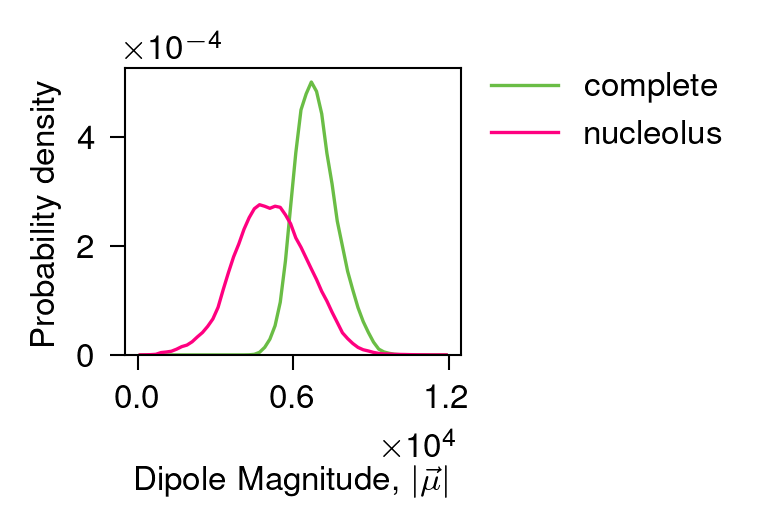

In [24]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(2.6, 1.8),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

vmin = np.min(
    [
        np.min(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
vmax = np.max(
    [
        np.max(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
bins = np.linspace(0, 1.2e4, 61)

for i, condition in enumerate(conditions):
    hist, bin_edges = np.histogram(
        polarization[condition]["dipole_magnitude"],
        bins=bins,
        density=True,
    )

    ax.plot(
        (bins[:-1] + bins[1:]) / 2,
        hist,
        label=condition,
        color=color_palette[condition],
    )

ax.set_xticks(
    [0, 6e3, 1.2e4], ["0", r"$6 \times 10^3$", r"$1.2 \times 10^4$"]
)
ax.set_ylim(bottom=0)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)

formatter = mpl.ticker.ScalarFormatter(
    useMathText=True, useOffset=False
)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.xaxis.set_major_formatter(formatter)

ax.set_ylabel("Probability density")
ax.set_xlabel(r"Dipole Magnitude, $|\vec{\mu}|$", labelpad=12)

ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.09))

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

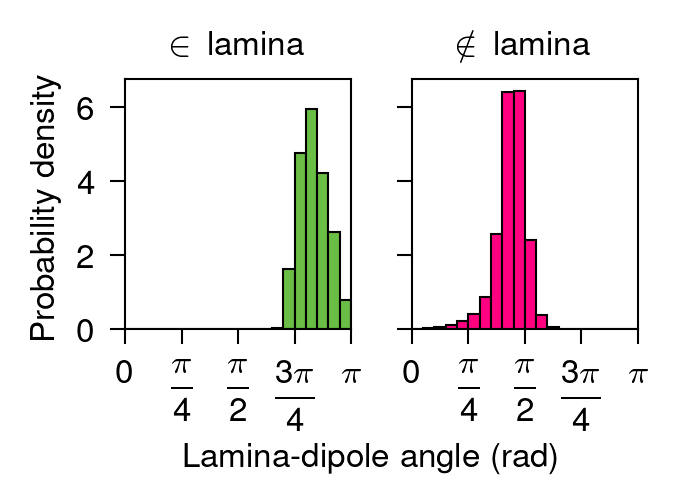

In [25]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(2.3, 1.8),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

bins = np.linspace(0, 1, 21)

for i, condition in enumerate(["complete", "nucleolus"]):
    ax[i].set_title(title[condition], fontsize=8)

    ax[i].hist(
        polarization[condition]["dipole_alignment"] / np.pi,
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
    )

    ax[i].set_xlim((0, 1))
    ax[i].set_xticks(
        [0, 0.25, 0.50, 0.75, 1.0],
        [
            r"0",
            r"$\dfrac{\pi}{4}$",
            r"$\dfrac{\pi}{2}$",
            r"$\dfrac{3\pi}{4}$",
            r"$\pi$",
        ],
    )
    ax[i].set_yticks([0, 2, 4, 6])

ax[0].set_ylabel("Probability density")

fig.supxlabel(
    r"Lamina-dipole angle (rad)", y=0.11, x=0.55, fontsize=8
)

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

## chr17


In [2]:
conditions = ["complete", "nucleolus"]

NUM_REPLICAS = 32
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

chromosome = 17

folder_num = 4 if chromosome == 1 else 5

OUTPUT_FOLDER = f"/scratch/mm146/Polarization/{folder_num}_IMR-90_hg38_chr{chromosome}/7_analysis/polarization/data"

In [3]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [4]:
color_palette

{'complete': '#6abd45',
 'control': '#404040',
 'lamina': '#25C8FA',
 'nucleolus': '#ff0080'}

In [5]:
title = {
    "complete": r"$\in\,\text{lamina}$",
    "nucleolus": r"$\notin\,\text{lamina}$",
}

In [6]:
# for testing the figures:
mpl.rcParams["figure.dpi"] = 300

### Concatenating the data


In [7]:
polarization = {}
for condition in conditions:
    polarization[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        print(f"Processing condition {condition}: replica {replica}")
        with h5py.File(
            os.path.join(
                OUTPUT_FOLDER,
                condition,
                f"polarization-replica{replica}.h5",
            )
        ) as saved_file:
            for key in saved_file.keys():
                if key not in polarization[condition].keys():
                    polarization[condition][key] = []
                polarization[condition][key].append(
                    saved_file[key][:]
                )

    for key in polarization[condition].keys():
        polarization[condition][key] = np.concatenate(
            polarization[condition][key], axis=0
        )

Processing condition complete: replica 1
Processing condition complete: replica 2
Processing condition complete: replica 3
Processing condition complete: replica 4
Processing condition complete: replica 5
Processing condition complete: replica 6
Processing condition complete: replica 7
Processing condition complete: replica 8
Processing condition complete: replica 9
Processing condition complete: replica 10
Processing condition complete: replica 11
Processing condition complete: replica 12
Processing condition complete: replica 13
Processing condition complete: replica 14
Processing condition complete: replica 15
Processing condition complete: replica 16
Processing condition complete: replica 17
Processing condition complete: replica 18
Processing condition complete: replica 19
Processing condition complete: replica 20
Processing condition complete: replica 21
Processing condition complete: replica 22
Processing condition complete: replica 23
Processing condition complete: replica 24
P

In [8]:
with h5py.File(
    os.path.join(
        OUTPUT_FOLDER,
        f"polarization-data-aggregated.h5",
    ),
    "w",
) as saving_file:
    for condition in conditions:
        group = saving_file.create_group(condition)
        for key in polarization[condition].keys():
            group.create_dataset(
                f"{key}",
                data=polarization[condition][key],
            )

### Plotting


In [9]:
polarization = {}
with h5py.File(
    os.path.join(
        OUTPUT_FOLDER,
        f"polarization-data-aggregated.h5",
    ),
    "r",
) as saved_file:
    for condition in saved_file.keys():
        polarization[condition] = {}
        group = saved_file[condition]
        for key in group.keys():
            polarization[condition][key] = group[key][:]

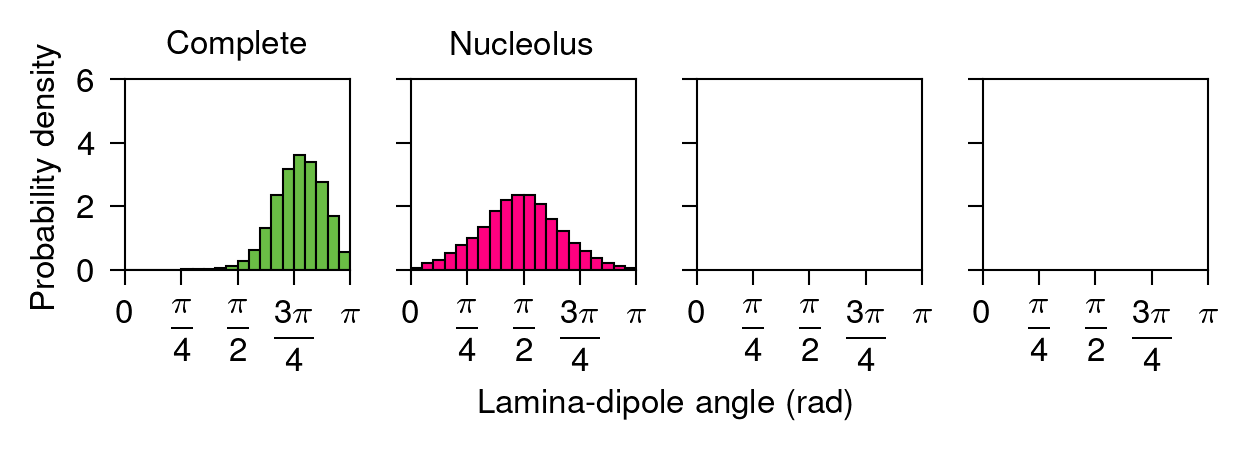

In [10]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=(4.2, 1.6),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

bins = np.linspace(0, 1, 21)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition.capitalize(), fontsize=8)

    ax[i].hist(
        polarization[condition]["dipole_alignment"] / np.pi,
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
    )

    ax[i].set_xlim((0, 1))
    ax[i].set_xticks(
        [0, 0.25, 0.50, 0.75, 1.0],
        [
            r"0",
            r"$\dfrac{\pi}{4}$",
            r"$\dfrac{\pi}{2}$",
            r"$\dfrac{3\pi}{4}$",
            r"$\pi$",
        ],
    )
    ax[i].set_yticks([0, 2, 4, 6])

ax[0].set_ylabel("Probability density")

fig.supxlabel(
    r"Lamina-dipole angle (rad)", y=0.11, x=0.535, fontsize=8
)

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

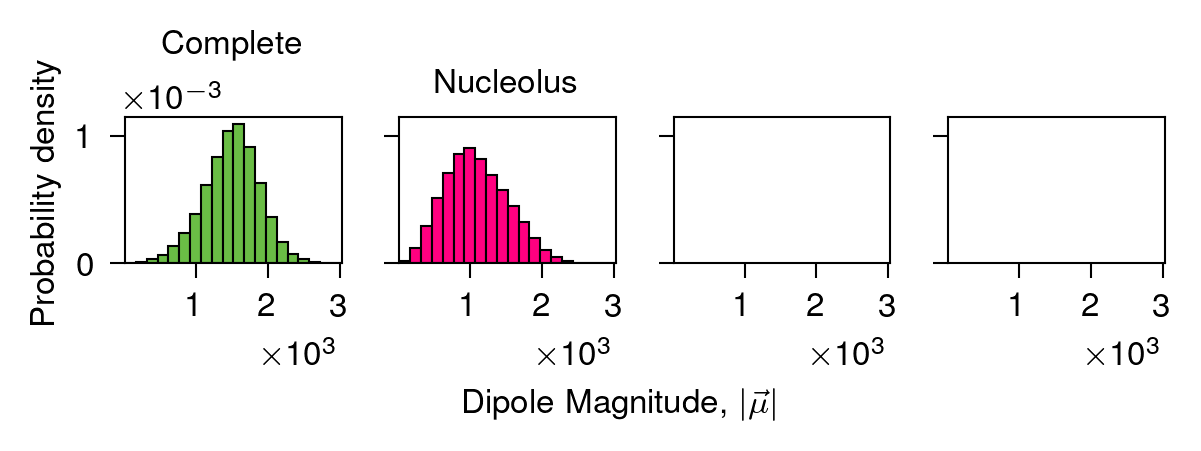

In [11]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=(4.2, 1.6),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

vmin = np.min(
    [
        np.min(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
vmax = np.max(
    [
        np.max(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
bins = np.linspace(vmin, vmax, 21)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition.capitalize(), fontsize=8)

    ax[i].hist(
        polarization[condition]["dipole_magnitude"],
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
    )

    # ax[i].set_xlim((0, 1))
    # ax[i].set_xticks(
    #     [0, 0.25, 0.50, 0.75, 1.0],
    #     [
    #         r"0",
    #         r"$\dfrac{\pi}{4}$",
    #         r"$\dfrac{\pi}{2}$",
    #         r"$\dfrac{3\pi}{4}$",
    #         r"$\pi$",
    #     ],
    # )
    # ax[i].set_yticks([0, 2, 4, 6])

ax[0].set_ylabel("Probability density")

fig.supxlabel(
    r"Dipole Magnitude, $|\vec{\mu}|$", y=0.11, x=0.535, fontsize=8
)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax[0].yaxis.set_major_formatter(formatter)
ax[0].set_xlim(vmin, vmax)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax[0].xaxis.set_major_formatter(formatter)


fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

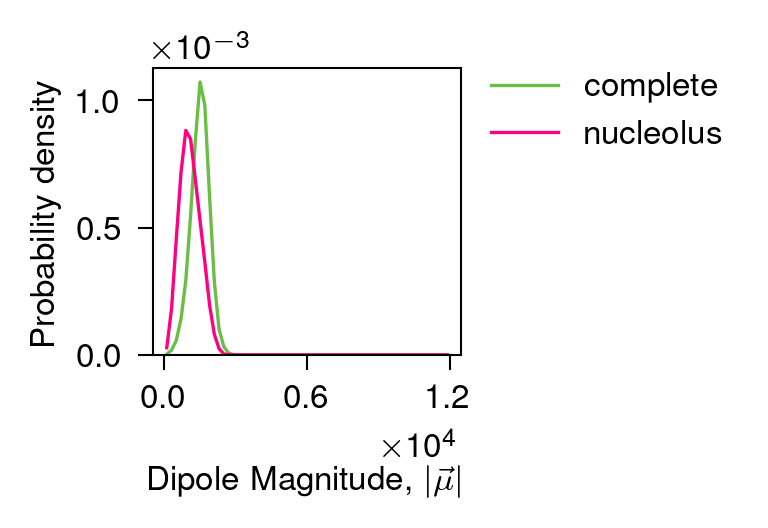

In [12]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(2.6, 1.8),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

vmin = np.min(
    [
        np.min(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
vmax = np.max(
    [
        np.max(polarization[condition]["dipole_magnitude"])
        for condition in conditions
    ]
)
bins = np.linspace(0, 1.2e4, 61)

for i, condition in enumerate(conditions):
    hist, bin_edges = np.histogram(
        polarization[condition]["dipole_magnitude"],
        bins=bins,
        density=True,
    )

    ax.plot(
        (bins[:-1] + bins[1:]) / 2,
        hist,
        label=condition,
        color=color_palette[condition],
    )

ax.set_xticks(
    [0, 6e3, 1.2e4], ["0", r"$6 \times 10^3$", r"$1.2 \times 10^4$"]
)
ax.set_ylim(bottom=0)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)

formatter = mpl.ticker.ScalarFormatter(
    useMathText=True, useOffset=False
)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.xaxis.set_major_formatter(formatter)

ax.set_ylabel("Probability density")
ax.set_xlabel(r"Dipole Magnitude, $|\vec{\mu}|$", labelpad=12)

ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.09))

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")

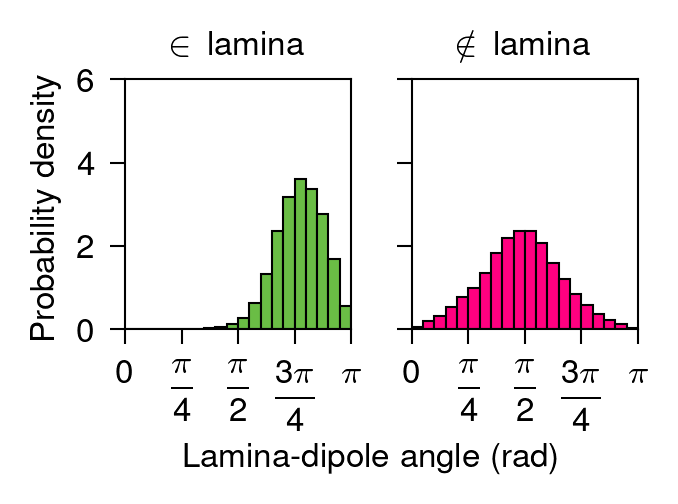

In [13]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(2.3, 1.8),
    sharex=True,
    sharey=True,
    # layout="constrained",
)

bins = np.linspace(0, 1, 21)

for i, condition in enumerate(["complete", "nucleolus"]):
    ax[i].set_title(title[condition], fontsize=8)

    ax[i].hist(
        polarization[condition]["dipole_alignment"] / np.pi,
        bins=bins,
        label=condition,
        density=True,
        color=color_palette[condition],
    )

    ax[i].set_xlim((0, 1))
    ax[i].set_xticks(
        [0, 0.25, 0.50, 0.75, 1.0],
        [
            r"0",
            r"$\dfrac{\pi}{4}$",
            r"$\dfrac{\pi}{2}$",
            r"$\dfrac{3\pi}{4}$",
            r"$\pi$",
        ],
    )
    ax[i].set_yticks([0, 2, 4, 6])

ax[0].set_ylabel("Probability density")

fig.supxlabel(
    r"Lamina-dipole angle (rad)", y=0.11, x=0.55, fontsize=8
)

fig.tight_layout()
# fig.savefig("figures/fig-dipole-alignment-one-chromosome.pdf")